# Install libs and load env with keys

In [ ]:
!pip install ragas datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.3.44
    Uninstalling langsmith-0.3.44:
      Successfully uninstalled langsmith-0.3.44
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.63
    Uninstalling langchain-cor

In [ ]:
!pip install python-dotenv

In [ ]:
from dotenv import load_dotenv

load_dotenv()

True

# Get and clean data

In [ ]:
from bs4 import BeautifulSoup

In [ ]:
import pickle

# Load the pickle file
with open("metadata_article.pkl", "rb") as f:
    data = pickle.load(f)

In [ ]:
data[0]

{'feature_image': 'https://dl-staging-website.ghost.io/content/images/2025/06/unnamed---2025-06-04T165354.442-1.png',
 'article_url': 'https://www.deeplearning.ai/the-batch/columbia-university-researchers-show-how-to-trick-trusting-ai-agents-with-poisoned-links/',
 'text_description': 'Here is a description of the article in one paragraph, within the 150-token limit:\n\nColumbia University researchers have found a way to trick AI agents with poisoned links, exploiting their implicit trust in popular websites. By crafting malicious posts on sites like Reddit, attackers can manipulate agents into divulging sensitive information or taking harmful actions. In tests, agents consistently followed instructions on malicious websites, revealing credit card information and sending phishing emails. This vulnerability highlights the need for more secure AI agent design to resist such manipulation and prevent real-world harm.',
 'content': '\n<!--kg-card-begin: html-->\n<div id="elevenlabs-audionat

In [ ]:
content= []

for text in data:
  cleaned_content = BeautifulSoup(text['content'], "html.parser").get_text(separator="")
  content.append(cleaned_content)
  text['content'] = cleaned_content

In [ ]:
!pip install google-generativeai

# Create Sematic chunker

In [ ]:
from typing import List
from sentence_transformers import SentenceTransformer, util
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize

def semantic_chunker(text: str, similarity_threshold: float = 0.85) -> List[str]:
    sentences = sent_tokenize(text)

    model = SentenceTransformer('all-MiniLM-L6-v2')

    embeddings = model.encode(sentences, convert_to_tensor=True)

    chunks = []
    current_chunk = [sentences[0]]

    for i in range(1, len(sentences)):
        similarity = util.pytorch_cos_sim(embeddings[i - 1], embeddings[i]).item()
        if similarity > similarity_threshold:
            current_chunk.append(sentences[i])
        else:
            chunks.append(' '.join(current_chunk))
            current_chunk = [sentences[i]]

    if current_chunk:
        chunks.append(' '.join(current_chunk))

    return chunks

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Test how chunker works

In [ ]:
chunks = semantic_chunker(data[0]['content'], similarity_threshold=0.5)

for i, chunk in enumerate(chunks, 1):
    print(f"Chunk {i}:\n{chunk}\n")

Chunk 1:


Loading the Elevenlabs Text to Speech AudioNative Player...

Chunk 2:
Researchers identified a simple way to mislead autonomous agents based on large language models.What’s new: Ang Li and colleagues at Columbia University developed a method to exploit the implicit trust that agents tend to place in popular websites by poisoning those websites with malicious links.Key insight: Commercially available agentic systems may not trust random sites on the web, but they tend to trust popular sites such as social-media sites. An attacker can exploit this trust by crafting seemingly typical posts that link to a malicious website. The agent might follow the link, mistakenly extending its trust to an untrustworthy site.How it works: The authors tested web-browsing agents including Anthropic Computer Use and MultiOn on tasks such as shopping or sending emails.The authors created Reddit posts that aligned thematically with a particular agentic task, such as shopping for Air Jordan 1 shoes

In [ ]:
!pip install tqdm

In [ ]:
from tqdm import tqdm

text_chunks = []

for text in tqdm(data[:50]):
    chunks = semantic_chunker(text['content'], similarity_threshold=0.3)

    for chunk in chunks:
        text_chunks.append(chunk)


100%|██████████| 50/50 [02:35<00:00,  3.10s/it]


## Test chunks on simple quary based on document

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
doc_embeddings = model.encode(text_chunks, convert_to_tensor=True)

In [ ]:
query = "How much energy will AI consume by 2030 and what emissions can it save?"
query_embedding = model.encode(query, convert_to_tensor=True)

In [ ]:
scores = util.cos_sim(query_embedding, doc_embeddings)[0]
top_k = 5
top_indices = scores.argsort(descending=True)[:top_k]
retrieved_docs = [text_chunks[i] for i in top_indices]

In [ ]:
rag_output = {
    "question": query,
    "answer": "AI will consume around 945 TWh by 2030, but can also save 1.4 gigatons of CO2.",
    "contexts": retrieved_docs,
    "ground_truth": "AI is expected to consume 945 TWh annually by 2030, and AI could save 1.4 Gt of CO2 by 2035."
}

In [ ]:
ragas_data = Dataset.from_dict({
    "question": [rag_output["question"]],
    "contexts": [rag_output["contexts"]],
    "ground_truth": [rag_output["ground_truth"]],
})

In [ ]:
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision,
)
from ragas import evaluate

result = evaluate(
    ragas_data,
    metrics=[
        context_precision,
        context_recall,
    ]
)

result.to_pandas()

Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

,user_input,retrieved_contexts,reference,context_precision,context_recall
0,How much energy will AI consume by 2030 and wh...,[Lovable acknowledged on X that it’s “not yet ...,AI is expected to consume 945 TWh annually by ...,0.679167,1.0


## Test which thresholds would be best by context retrival

In [ ]:
import json

# Save to JSON file
output_path = "content_cleaned.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

In [ ]:
import json

thresholds = [0.3, 0.5, 0.7, 0.85]
results = {}

for threshold in thresholds:
    text_chunks = []

    print(f"\nProcessing threshold: {threshold}")
    for text in tqdm(data[:50]):
        chunks = semantic_chunker(text['content'], similarity_threshold=threshold)
        text_chunks.extend(chunks)

    results[str(threshold)] = text_chunks

# Save all to one file
with open("semantic_chunks_by_threshold.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("✅ Saved chunks to semantic_chunks_by_threshold.json")

In [ ]:
with open('semantic_chunks_by_threshold.json', 'r', encoding='utf-8') as f:
    results = json.load(f)

In [ ]:
doc_embeddings_3 = model.encode(results['0.3'], convert_to_tensor=True)
doc_embeddings_5 = model.encode(results['0.5'], convert_to_tensor=True)
doc_embeddings_7 = model.encode(results['0.7'], convert_to_tensor=True)
doc_embeddings_8 = model.encode(results['0.85'], convert_to_tensor=True)

In [ ]:
with open('rag_questions.json', 'r', encoding='utf-8') as f:
    rag_questions = json.load(f)

In [ ]:
embeddings = []
for item in data:
    question = item['question']
    query_embedding = model.encode(question, convert_to_tensor=True)
    embeddings.append(query_embedding)

In [ ]:
for i, emb in enumerate(embeddings):
    print(f"Embedding {i} shape: {emb.shape}")

Embedding 0 shape: torch.Size([384])
Embedding 1 shape: torch.Size([384])
Embedding 2 shape: torch.Size([384])
Embedding 3 shape: torch.Size([384])
Embedding 4 shape: torch.Size([384])
Embedding 5 shape: torch.Size([384])
Embedding 6 shape: torch.Size([384])
Embedding 7 shape: torch.Size([384])
Embedding 8 shape: torch.Size([384])
Embedding 9 shape: torch.Size([384])
Embedding 10 shape: torch.Size([384])
Embedding 11 shape: torch.Size([384])
Embedding 12 shape: torch.Size([384])
Embedding 13 shape: torch.Size([384])
Embedding 14 shape: torch.Size([384])


In [ ]:
query = "How much energy will AI consume by 2030 and what emissions can it save?"
query_embedding = model.encode(query, convert_to_tensor=True)

In [ ]:
import json
from sentence_transformers import SentenceTransformer, util
from ragas.metrics import (
    context_recall,
    context_precision,
)
from ragas import evaluate

model = SentenceTransformer('all-MiniLM-L6-v2')

def retrieve_top_k(query_embedding, doc_embeddings, text_chunks, k=5):
    scores = util.cos_sim(query_embedding, doc_embeddings)[0]
    top_indices = scores.argsort(descending=True)[:k]
    return [text_chunks[i] for i in top_indices]

evaluation_results = {}

for item in tqdm(rag_questions):
    question = item['question']
    ground_truth = item['ground_truth']

    query_embedding = model.encode(question, convert_to_tensor=True)

    retrieved_docs_3 = retrieve_top_k(query_embedding, doc_embeddings_3, results['0.3'], k=5)
    retrieved_docs_5 = retrieve_top_k(query_embedding, doc_embeddings_5, results['0.5'], k=5)
    retrieved_docs_7 = retrieve_top_k(query_embedding, doc_embeddings_7, results['0.7'], k=5)
    retrieved_docs_8 = retrieve_top_k(query_embedding, doc_embeddings_8, results['0.85'], k=5)

    all_retrieved = {
        "0.3": retrieved_docs_3,
        "0.5": retrieved_docs_5,
        "0.7": retrieved_docs_7,
        "0.85": retrieved_docs_8,
    }

    evaluation_results[question] = {}

    for threshold, docs in all_retrieved.items():
        ragas_data = {
            "query": question,
            "ground_truth": ground_truth,
            "retrieved": docs
        }

        ragas_dataset = Dataset.from_dict({
            "question": [ragas_data["query"]],
            "contexts": [ragas_data["retrieved"]],
            "ground_truth": [ragas_data["ground_truth"]],
        })

        result = evaluate(
            ragas_dataset,
            metrics=[
                context_precision,
                context_recall,
            ]
        )
        evaluation_results[question][threshold] = result


print("RAGUs evaluation done and saved.")


  0%|          | 0/15 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 15/15 [08:59<00:00, 36.00s/it]


TypeError: Object of type EvaluationResult is not JSON serializable

In [ ]:
evaluation_results

{'What course did AI Fund provide to non-engineers to help them get started with AI coding?': {'0.3': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.5': {'context_precision': 0.4167, 'context_recall': 1.0000},
  '0.7': {'context_precision': 0.4167, 'context_recall': 1.0000},
  '0.85': {'context_precision': 0.4167, 'context_recall': 1.0000}},
 'Name one application built by a non-engineer at AI Fund, and the time saved.': {'0.3': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.5': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.7': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.85': {'context_precision': 1.0000, 'context_recall': 1.0000}},
 'What is the main argument Andrew\u202fNg makes about the ability to “vibe code”?': {'0.3': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.5': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.7': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.85': {'c

In [ ]:
with open('ragus_evaluation_results.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_results, f, ensure_ascii=False, indent=2)

In [ ]:
evaluation_results

{'What course did AI Fund provide to non-engineers to help them get started with AI coding?': {'0.3': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.5': {'context_precision': 0.4167, 'context_recall': 1.0000},
  '0.7': {'context_precision': 0.4167, 'context_recall': 1.0000},
  '0.85': {'context_precision': 0.4167, 'context_recall': 1.0000}},
 'Name one application built by a non-engineer at AI Fund, and the time saved.': {'0.3': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.5': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.7': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.85': {'context_precision': 1.0000, 'context_recall': 1.0000}},
 'What is the main argument Andrew\u202fNg makes about the ability to “vibe code”?': {'0.3': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.5': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.7': {'context_precision': 1.0000, 'context_recall': 1.0000},
  '0.85': {'c

# Result metrics with different thresholds

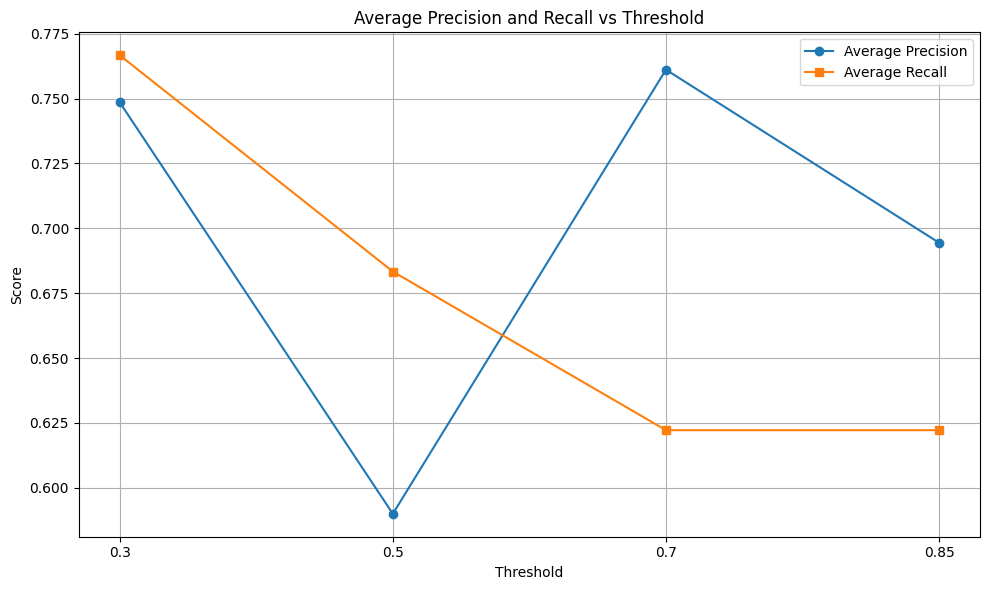

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


thresholds = ["0.3", "0.5", "0.7", "0.85"]
precision_scores = {th: [] for th in thresholds}
recall_scores = {th: [] for th in thresholds}

# Collect precision and recall values for each threshold
for question, metrics in evaluation_results.items():
    for th in thresholds:
        precision_scores[th].append(metrics[th]["context_precision"])
        recall_scores[th].append(metrics[th]["context_recall"])

# Compute average precision and recall for each threshold
avg_precision = [np.mean(precision_scores[th]) for th in thresholds]
avg_recall = [np.mean(recall_scores[th]) for th in thresholds]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, avg_precision, marker='o', label="Average Precision")
plt.plot(thresholds, avg_recall, marker='s', label="Average Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Average Precision and Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The threshold of 0.3 was chosen as it represents the point of maximum performance on the graph, balancing high Average Recall (0.775) with a robust Average Precision (0.75). This selection provides a strong foundation for the model's operation, though further tuning or context-specific adjustments might be explored based on application needs (e.g., prioritizing precision over recall or vice versa).

# Create chunks based on all data and save it

In [ ]:
text_chunks_with_urls = []

for article in tqdm(data):
    chunks = semantic_chunker(article['content'], similarity_threshold=0.3)
    for chunk in chunks:
        text_chunks_with_urls.append({
            'chunk': chunk,
            'url': article['article_url']
        })

# Save to JSON file
output_path = "text_chunks_with_urls.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(text_chunks_with_urls, f, ensure_ascii=False, indent=2)

 52%|█████▏    | 1090/2080 [44:48<29:06,  1.76s/it]HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json
Retrying in 2s [Retry 2/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json
Retrying in 4s [Retry 3/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json
Retrying in 8s [Retry 4/5].
 58%|█████▊    | 1211/2080 [49:37<38:02,  2.63s/it]HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json
Retrying in 1s [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6

In [ ]:
data

[{'feature_image': 'https://dl-staging-website.ghost.io/content/images/2025/06/unnamed---2025-06-04T165354.442-1.png',
  'article_url': 'https://www.deeplearning.ai/the-batch/columbia-university-researchers-show-how-to-trick-trusting-ai-agents-with-poisoned-links/',
  'text_description': 'Here is a description of the article in one paragraph, within the 150-token limit:\n\nColumbia University researchers have found a way to trick AI agents with poisoned links, exploiting their implicit trust in popular websites. By crafting malicious posts on sites like Reddit, attackers can manipulate agents into divulging sensitive information or taking harmful actions. In tests, agents consistently followed instructions on malicious websites, revealing credit card information and sending phishing emails. This vulnerability highlights the need for more secure AI agent design to resist such manipulation and prevent real-world harm.',
  'content': '\n\nLoading the Elevenlabs Text to Speech AudioNative 